# VJeaNETte Reproducibility Notebook

## 1. Project overview 

### VJeaNETte inference reproducibility

This notebook demonstrates:
- loading trained UNet1D model
- FASTQ preprocessing
- V/J/CDR3 inference
- running the full pipeline

The goal is to reproduce inference results from the paper/project.

## 2. Imports and environment

In [1]:
import argparse
import csv
import logging
import time

import mmap
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import IterableDataset

In [2]:
import sys
import torch

print(sys.version)
print(torch.__version__)

3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
2.5.1+cu121


## 3. Constants and configuration

### Global constants and thresholds

In [3]:
MAX_LEN = 512

RC_TABLE = torch.tensor([3,2,1,0,4,5], dtype=torch.uint8)

DEFAULT_THRESHOLDS = {
    "v_exist": 0.02,
    "j_exist": 0.02,
    "cdr_exist": 0.02,
    "mask": 0.04
}

## 4. FASTQ preprocessing

### FASTQ streaming dataset

The dataset implementation uses:

- memory mapped FASTQ reading (`mmap`)
- iterable dataset design
- multithreaded workers
- byte-level nucleotide encoding

This allows efficient processing of very large sequencing datasets.

In [4]:
CHAR_MAP = np.full(256, 4, dtype=np.uint8)

CHAR_MAP[ord("A")] = 0
CHAR_MAP[ord("C")] = 1
CHAR_MAP[ord("G")] = 2
CHAR_MAP[ord("T")] = 3
CHAR_MAP[ord("N")] = 4
CHAR_MAP[ord("P")] = 5

In [5]:
def seq_to_indices_bytes(seq_bytes):
    arr = np.frombuffer(seq_bytes, dtype=np.uint8)
    return CHAR_MAP[arr]
def filling_bytes(seq_bytes):
    seq = seq_bytes[:MAX_LEN]
    if len(seq) < MAX_LEN:
        seq += b"P" * (MAX_LEN - len(seq))
    return seq


In [6]:

class FastqDataset(IterableDataset): 

    def __init__(self, path, batch_size, num_workers):
        self.path = path
        self.batch_size = batch_size
        self.num_workers = num_workers

    def parse_fastq(self, worker_id):

        f = open(self.path, "rb")
        mm = mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ)

        size = mm.size()
        chunk = size // self.num_workers

        start = worker_id * chunk
        end = size if worker_id == self.num_workers-1 else (worker_id+1)*chunk

        mm.seek(start)

        if start != 0:
            mm.readline()
            while True:
                pos = mm.tell()
                line = mm.readline()
                if not line:
                    break
                if line.startswith(b'@'):
                    mm.seek(pos)
                    break

        batch = []
        ids = []

        while mm.tell() < end:

            header = mm.readline()
            if not header:
                break

            seq = mm.readline().rstrip()
            mm.readline()
            mm.readline()

            read_id = header[1:].split()[0].decode()

            seq = filling_bytes(seq)

            batch.append(seq_to_indices_bytes(seq))
            ids.append(read_id)

            if len(batch) == self.batch_size:
                yield torch.from_numpy(np.stack(batch)).long(), ids
                batch, ids = [], []

        if batch:
            yield torch.from_numpy(np.stack(batch)).long(), ids

        mm.close()
        f.close()

    def __iter__(self):

        worker_info = torch.utils.data.get_worker_info()

        if worker_info is None:
            worker_id = 0
        else:
            worker_id = worker_info.id

        yield from self.parse_fastq(worker_id)

## 5. CUDA setup

In [7]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

DEVICE: cuda


## 6. UNet architecture

### Model architecture

The model is based on a 1D U-Net encoder-decoder architecture
with separate heads for:
- V segment
- J segment
- CDR3 region

In [8]:
class UNet1D_Embed(nn.Module):
    def __init__(self, embed_dim=32, out_channels=1, features=[8,16,64,64]):
        super().__init__()
        PADDING_IDX = 5
        self.embed = nn.Embedding(num_embeddings=6, embedding_dim=embed_dim, padding_idx=PADDING_IDX)
        
        in_channels = embed_dim
        
        # Encoder
        self.enc1 = self._encoder_block(in_channels, features[0])
        self.enc2 = self._encoder_block(features[0], features[1])
        self.enc3 = self._encoder_block(features[1], features[2])
        self.enc4 = self._encoder_block(features[2], features[3])
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv1d(features[3], features[3]*2, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[3]*2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv1d(features[3]*2, features[3]*2, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[3]*2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )
        
        # Decoder
        self.up4 = nn.ConvTranspose1d(features[3]*2, features[3], kernel_size=2, stride=2)
        self.dec4 = self._decoder_block(features[3]+features[2], features[2])
        
        self.up3 = nn.ConvTranspose1d(features[2], features[2], kernel_size=2, stride=2)
        self.dec3 = self._decoder_block(features[2]+features[1], features[1])
        
        self.up2 = nn.ConvTranspose1d(features[1], features[1], kernel_size=2, stride=2)
        self.dec2 = self._decoder_block(features[1]+features[0], features[0])
        
        self.up1 = nn.ConvTranspose1d(features[0], features[0], kernel_size=2, stride=2)
        
        self.final_conv = nn.Sequential(
            nn.Conv1d(features[0], features[0], kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[0]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv1d(features[0], features[0], kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[0]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )
        
        self.v_head = nn.Sequential(
            nn.Conv1d(features[0], features[0]//2, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(features[0]//2, out_channels, kernel_size=1)
        )
        self.j_head = nn.Sequential(
            nn.Conv1d(features[0], features[0]//2, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(features[0]//2, out_channels, kernel_size=1)
        )
        self.cdr_head = nn.Sequential(
            nn.Conv1d(features[0], features[0]//2, kernel_size = 1),
            nn.ReLU(inplace = True),
            nn.Conv1d(features[0]//2, out_channels, kernel_size = 1)
        )
        
    
    def _encoder_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Conv1d(out_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.MaxPool1d(2)
        )
    
    def _decoder_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Conv1d(out_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35)
        )
    
    def forward(self, x):
        """
        x: [B, L] LongTensor индексы 0..5
        """
        x = self.embed(x).transpose(1, 2)  # [B, embed_dim, L]
        
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        
        b = self.bottleneck(e4)
        
        d4 = self.up4(b)
        d4 = torch.cat((d4, e3), dim=1)
        d4 = self.dec4(d4)
        
        d3 = self.up3(d4)
        d3 = torch.cat((d3, e2), dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat((d2, e1), dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = self.final_conv(d1)
        
        v_out = self.v_head(d1)
        j_out = self.j_head(d1)
        cdr_out = self.cdr_head(d1)
        
        return cdr_out.squeeze(1), v_out.squeeze(1), j_out.squeeze(1)

## 7. Utility functions

In [9]:
def reverse_complement(x):
    """Reverse complement"""
    return RC_TABLE.to(x.device)[x].flip(1)

def get_intervals_fast(probs, thr):
    """Fast intervals defining"""
    mask = probs > thr
    
    any_mask = mask.any(1)
    mask_int = mask.to(torch.int8)
    starts = torch.argmax(mask_int, dim=1)
    ends = mask.size(1) - torch.argmax(mask_int.flip(1), dim=1) - 1
    
    starts[~any_mask] = -1
    ends[~any_mask] = -1
    
    return starts, ends

def calculate_scores(has_v, has_j, max_v, max_j):
    """Score calculation"""
    return 2*has_v.float() + 2*has_j.float() + max_v + max_j

def select_best_strand(vf, vr, jf, jr, has_vf, has_vr, has_jf, has_jr):
    """Select best strand (forward/reverse)"""
    max_vf = vf.max(1).values
    max_vr = vr.max(1).values
    max_jf = jf.max(1).values
    max_jr = jr.max(1).values
    
    score_f = calculate_scores(has_vf, has_jf, max_vf, max_jf)
    score_r = calculate_scores(has_vr, has_jr, max_vr, max_jr)
    
    return score_f >= score_r, max_vf, max_vr, max_jf, max_jr

## 8. Inference pipeline

### Inference pipeline

The inference runner:
1. loads FASTQ reads
2. generates reverse complements
3. predicts V/J/CDR3 probabilities
4. selects the best strand
5. exports results to CSV

In [31]:
import time
import torch
import logging
from torch.utils.data import DataLoader
import numpy as np
import csv
from vjeanette.parser import FastqDataset
from vjeanette.utils import reverse_complement, select_best_strand
from vjeanette.config import DEFAULT_THRESHOLDS

IDX_TO_CHAR = np.array(['A', 'C', 'G', 'T', 'N', 'P'])

class InferenceRunner:
    def __init__(self, model, device='cuda', thresholds=None):
        self.model = model
        self.device = device
        self.thresholds = thresholds or DEFAULT_THRESHOLDS
        self.logger = self._setup_logger()

    def _setup_logger(self):
        logger = logging.getLogger("inference")
        logger.setLevel(logging.INFO)
        return logger

    def add_log_handler(self, log_file):
        handler = logging.FileHandler(log_file)
        handler.setFormatter(logging.Formatter("%(asctime)s | %(message)s"))
        self.logger.addHandler(handler)
        self.logger.propagate = False
    def _process_batch(self, x, read_ids):
        bs = len(read_ids)

        x_rc = reverse_complement(x)
        x = torch.cat([x, x_rc], 0).to(self.device, non_blocking=True)
        is_cuda = DEVICE == 'cuda'
        with torch.inference_mode(), torch.autocast(device = "cuda", enabled = 'is_cuda'):
            cdr3_logits, v_logits, j_logits = self.model(x)

        v_probs = torch.sigmoid(v_logits)
        j_probs = torch.sigmoid(j_logits)
        cdr3_probs = torch.sigmoid(cdr3_logits)

        vf, vr = v_probs[:bs], v_probs[bs:]
        jf, jr = j_probs[:bs], j_probs[bs:]

        # исправление бага
        cdrs, cdre = cdr3_probs[:bs], cdr3_probs[bs:]

        has_vf = vf.max(1).values > self.thresholds['v_exist']
        has_vr = vr.max(1).values > self.thresholds['v_exist']

        has_jf = jf.max(1).values > self.thresholds['j_exist']
        has_jr = jr.max(1).values > self.thresholds['j_exist']

        has_cdrf = cdrs.max(1).values > self.thresholds['cdr_exist']
        has_cdrr = cdre.max(1).values > self.thresholds['cdr_exist']

        choose_f, max_vf, max_vr, max_jf, max_jr = select_best_strand(
            vf, vr,
            jf, jr,
            has_vf, has_vr,
            has_jf, has_jr
        )

        return self._prepare_results(
            read_ids,
            choose_f,
            has_vf, has_jf,
            has_vr, has_jr,
            has_cdrf, has_cdrr,
            max_vf, max_vr,
            max_jf, max_jr
        )


    def _prepare_results(
        self,
        read_ids,
        choose_f,
        has_vf, has_jf,
        has_vr, has_jr,
        has_cdrf, has_cdrr,
        max_vf, max_vr,
        max_jf, max_jr
    ):

        choose_f = choose_f.cpu().numpy()

        has_vf = has_vf.cpu().numpy().astype(np.int8)
        has_jf = has_jf.cpu().numpy().astype(np.int8)
        has_cdrf = has_cdrf.cpu().numpy().astype(np.int8)

        has_vr = has_vr.cpu().numpy().astype(np.int8)
        has_jr = has_jr.cpu().numpy().astype(np.int8)
        has_cdrr = has_cdrr.cpu().numpy().astype(np.int8)

        max_vf = max_vf.cpu().numpy()
        max_jf = max_jf.cpu().numpy()

        max_vr = max_vr.cpu().numpy()
        max_jr = max_jr.cpu().numpy()

        rows = []

        for i, rid in enumerate(read_ids):
            if choose_f[i]:
                rows.append([
                    rid,
                    "forward",
                    2*has_vf[i] + 2*has_jf[i] + max_vf[i] + max_jf[i],
                    has_vf[i],
                    has_jf[i],
                    has_cdrf[i]
                ])
            else:
                rows.append([
                    rid,
                    "reverse",
                    2*has_vr[i] + 2*has_jr[i] + max_vr[i] + max_jr[i],
                    has_vr[i],
                    has_jr[i],
                    has_cdrr[i]
                ])

        return rows


    def run(
        self,
        fastq_file,
        output_csv,
        batch_size=32768,
        num_workers=1
    ):
        import csv

        self.logger.info("Run inference")

        dataset = FastqDataset(
            fastq_file,
            batch_size,
            num_workers
        )

        loader = DataLoader(
            dataset,
            batch_size=None,
            num_workers=num_workers,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4
        )

        self.model.eval()

        start = time.perf_counter()
        total_reads = 0

        with open(output_csv, "w", newline="") as csv_file:

            writer = csv.writer(csv_file)

            writer.writerow([
                "id",
                "strand",
                "score",
                "has_v",
                "has_j",
                "has_cdr3"
            ])

            for x, read_ids in loader:
                total_reads += len(read_ids)

                rows = self._process_batch(x, read_ids)

                writer.writerows(rows)

        elapsed = time.perf_counter() - start

        self.logger.info(f"TIME: {elapsed:.2f}")
        self.logger.info(f"READS: {total_reads}")
        self.logger.info(f"SPEED: {total_reads / elapsed:.2f} reads/sec")

## 9. Configuration loading

In [32]:
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib

In [33]:
MODEL_PATH = "../weights/model_custom.pth"

model = UNet1D_Embed().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

print("Model loaded")

Model loaded


## 10. Running Inference

In [34]:
runner = InferenceRunner(
    model=model,
    device=DEVICE,
    thresholds=DEFAULT_THRESHOLDS
)

runner.run(
    fastq_file="./fn_v.fastq",
    output_csv="../out/fn_v.csv",
    batch_size=16384,
    num_workers=1
)

INFO:inference:Run inference


In [3]:
import pandas as pd

model_output = pd.read_csv("../out/test_out_18748717_2.csv")

model_output.head()

,id,strand,score,has_v,has_j,has_cdr3
0,SRR18748717.1,forward,5.960464e-08,0,0,0
1,SRR18748717.2,reverse,6.318092e-06,0,0,0
2,SRR18748717.3,reverse,4.172325e-07,0,0,0
3,SRR18748717.4,reverse,1.430511e-06,0,0,0
4,SRR18748717.5,reverse,1.192093e-07,0,0,0


In [4]:
model_output.shape

(38008234, 6)

In [5]:
print("Total reads:", len(model_output))
print("Reads with V:", model_output.has_v.mean())
print("Reads with J:", model_output.has_j.mean())

Total reads: 38008234
Reads with V: 0.0018964837987473977
Reads with J: 0.001845836878398507


## 11. Uploading Vidjil results

In [6]:
vidjil_srr_ids=set()
with open('/home/mbelyakov/vidjil_install/vidjil-algo-2024.02/my_results_m18748717.fastq/m18748717.detected.vdj.fa') as f:
    l = f.readline()
    while l:
        if l.startswith('>'):
            vidjil_srr_ids.add(l.split()[0][1:])
        l = f.readline()


## 12.Metrics counting

In [7]:
model_output = model_output.rename(columns={'read_id':'sequence_id'})

In [8]:
data_reference = pd.read_csv('../data/test_18748717_reference.tsv', delimiter=',')

In [9]:
data_reference.shape

(38008234, 15)

In [10]:
data_reference['has_v_ok'] =  (data_reference.has_v &(data_reference.best_v_identity > 80) &(data_reference.best_v_score > 50) )
          #  df.has_j &
            
         #   (df.best_j_identity > 88) &
            
          #  (df.best_j_score > 40)
        
data_reference['has_j_ok'] =  ( data_reference.has_j &(data_reference.best_j_identity > 88) & (data_reference.best_j_score > 40))
            #df.has_v &
           
          #  (df.best_v_identity > 80) &
            
          #  (df.best_v_score > 50) &
model_output['has_v_ok'] = model_output['has_v'].copy()
model_output['has_j_ok'] = model_output['has_j'].copy()


In [11]:
data_reference

,Unnamed: 0,sequence,sequence_id,v_sequence_start,v_sequence_end,j_sequence_start,j_sequence_end,cdr3_start,cdr3_end,best_v_identity,best_j_identity,best_v_score,best_j_score,has_v,has_j,has_v_ok,has_j_ok
0,0,ATTTTCAAGCTTTTGATGAGGACACTGGACTACCAGCCCATGCAAG...,SRR18748717.1,10.0,32.0,210.0,216.0,NaN,NaN,78.261,100.0,22.092,14.146,True,True,False,False
1,1,TCCTCATCTTCCTTTTTCTCACTGTCTGACTTTTCCTCACTGTCGG...,SRR18748717.10,36.0,55.0,80.0,87.0,65.0,84.0,85.000,100.0,23.650,16.069,True,True,False,False
2,2,CTACCCTAGCATCACACACCGCACAATCCCCTATCTAGGCCTTCTT...,SRR18748717.100,50.0,84.0,110.0,119.0,NaN,NaN,80.000,100.0,34.557,19.914,True,True,False,False
3,3,GGTAGGAAGAAAGCTAGAGGTGGCCTGCAAGCTGGGCTGGGGCCCC...,SRR18748717.1000,61.0,72.0,NaN,NaN,NaN,NaN,100.000,NaN,20.534,NaN,True,False,False,False
4,4,TGACAAGAATCATTAATGCTTTCTGGGGAAAATAATGGAGTTTCCT...,SRR18748717.10000,75.0,95.0,198.0,206.0,NaN,NaN,80.952,100.0,22.092,17.992,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38008229,38008229,CACAACTCCCAAGGCTGGATAGGTAAGGAGGATCCGGGCCAAAGGG...,SRR18748717.9999992,133.0,145.0,148.0,154.0,NaN,NaN,100.000,100.0,22.092,14.146,True,True,False,False
38008230,38008230,GGAAAGCCCCAGGGCACTGTGGCCAGGGTTCACATTGGCCAAGTTA...,SRR18748717.9999995,8.0,19.0,61.0,69.0,NaN,NaN,100.000,100.0,20.534,17.992,True,True,False,False
38008231,38008231,GGACTCATATGCAAGATTGCTGACTTCGGATTGGCCCGATTGATAG...,SRR18748717.9999997,46.0,83.0,NaN,NaN,NaN,NaN,65.789,NaN,20.534,NaN,True,False,False,False
38008232,38008232,CGTCTCACAAAAAAAAAAAAAAGAAAAAAAAAAGTAAAGTAACGAG...,SRR18748717.9999998,12.0,39.0,84.0,90.0,NaN,NaN,75.000,100.0,23.650,14.146,True,True,False,False


In [12]:
model_output['sequence_id'] = model_output['id'].copy()

In [13]:
data_merged = data_reference.merge(model_output,on = 'sequence_id')

### VJeaNETte metrics

In [14]:
data_merged

,Unnamed: 0,sequence,sequence_id,v_sequence_start,v_sequence_end,j_sequence_start,j_sequence_end,cdr3_start,cdr3_end,best_v_identity,...,has_v_ok_x,has_j_ok_x,id,strand,score,has_v_y,has_j_y,has_cdr3,has_v_ok_y,has_j_ok_y
0,0,ATTTTCAAGCTTTTGATGAGGACACTGGACTACCAGCCCATGCAAG...,SRR18748717.1,10.0,32.0,210.0,216.0,NaN,NaN,78.261,...,False,False,SRR18748717.1,forward,5.960464e-08,0,0,0,0,0
1,1,TCCTCATCTTCCTTTTTCTCACTGTCTGACTTTTCCTCACTGTCGG...,SRR18748717.10,36.0,55.0,80.0,87.0,65.0,84.0,85.000,...,False,False,SRR18748717.10,forward,5.960464e-08,0,0,0,0,0
2,2,CTACCCTAGCATCACACACCGCACAATCCCCTATCTAGGCCTTCTT...,SRR18748717.100,50.0,84.0,110.0,119.0,NaN,NaN,80.000,...,False,False,SRR18748717.100,reverse,1.031160e-05,0,0,0,0,0
3,3,GGTAGGAAGAAAGCTAGAGGTGGCCTGCAAGCTGGGCTGGGGCCCC...,SRR18748717.1000,61.0,72.0,NaN,NaN,NaN,NaN,100.000,...,False,False,SRR18748717.1000,forward,5.960464e-08,0,0,0,0,0
4,4,TGACAAGAATCATTAATGCTTTCTGGGGAAAATAATGGAGTTTCCT...,SRR18748717.10000,75.0,95.0,198.0,206.0,NaN,NaN,80.952,...,False,False,SRR18748717.10000,reverse,5.960464e-08,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38008229,38008229,CACAACTCCCAAGGCTGGATAGGTAAGGAGGATCCGGGCCAAAGGG...,SRR18748717.9999992,133.0,145.0,148.0,154.0,NaN,NaN,100.000,...,False,False,SRR18748717.9999992,reverse,2.384186e-06,0,0,0,0,0
38008230,38008230,GGAAAGCCCCAGGGCACTGTGGCCAGGGTTCACATTGGCCAAGTTA...,SRR18748717.9999995,8.0,19.0,61.0,69.0,NaN,NaN,100.000,...,False,False,SRR18748717.9999995,reverse,1.788139e-07,0,0,0,0,0
38008231,38008231,GGACTCATATGCAAGATTGCTGACTTCGGATTGGCCCGATTGATAG...,SRR18748717.9999997,46.0,83.0,NaN,NaN,NaN,NaN,65.789,...,False,False,SRR18748717.9999997,reverse,1.662970e-05,0,0,0,0,0
38008232,38008232,CGTCTCACAAAAAAAAAAAAAAGAAAAAAAAAAGTAAAGTAACGAG...,SRR18748717.9999998,12.0,39.0,84.0,90.0,NaN,NaN,75.000,...,False,False,SRR18748717.9999998,forward,5.960464e-08,0,0,0,0,0


In [15]:
TP_v_model, TN_v_model, FP_v_model, FN_v_model = len(data_merged[(data_merged['has_v_ok_x'].eq(1)) & (data_merged['has_v_ok_y'].eq(1))]),\
                                        len(data_merged[(~data_merged['has_v_ok_x'].eq(1)) & (~data_merged['has_v_ok_y'].eq(1))]),\
                                        len(data_merged[(~data_merged['has_v_ok_x'].eq(1)) & (data_merged['has_v_ok_y'].eq(1))]),\
                                        len(data_merged[(data_merged['has_v_ok_x'].eq(1)) & (~data_merged['has_v_ok_y'].eq(1))])
precision_v_model, recall_v_model = TP_v_model / (TP_v_model + FP_v_model + 1e-9), TP_v_model / (TP_v_model + FN_v_model + 1e-9)

In [16]:
data_merged['has_cdr3_y'] = data_merged['has_v_ok_y'].eq(1) & data_merged['has_j_ok_y'].eq(1)
data_merged['has_cdr3_x'] = data_merged['has_v_ok_x'].eq(1) & data_merged['has_j_ok_x'].eq(1)

In [17]:
TP_cdr_model, TN_cdr_model, FP_cdr_model, FN_cdr_model = len(data_merged[(data_merged['has_cdr3_x']) & (data_merged['has_cdr3_y'])]),\
                                        len(data_merged[(~data_merged['has_cdr3_x']) & (~data_merged['has_cdr3_y'])]),\
                                        len(data_merged[(~data_merged['has_cdr3_x']) & (data_merged['has_cdr3_y'])]),\
                                        len(data_merged[(data_merged['has_cdr3_x']) & (~data_merged['has_cdr3_y'])])
precision_cdr_model, recall_cdr_model = TP_cdr_model / (TP_cdr_model + FP_cdr_model + 1e-9), TP_cdr_model / (TP_cdr_model + FN_cdr_model + 1e-9)

In [18]:
precision_cdr_model, recall_cdr_model

(0.43794730576710067, 0.9994108598173338)

In [19]:
print(data_merged['has_cdr3_x'].value_counts())
print(data_merged['has_cdr3_y'].value_counts())

has_cdr3_x
False    37977681
True        30553
Name: count, dtype: int64
has_cdr3_y
False    37938511
True        69723
Name: count, dtype: int64


In [20]:
print(data_merged['has_v_ok_x'].value_counts())
print(data_merged['has_j_ok_x'].value_counts())

print(data_merged['has_v_ok_y'].value_counts())
print(data_merged['has_j_ok_y'].value_counts())

has_v_ok_x
False    37918414
True        89820
Name: count, dtype: int64
has_j_ok_x
False    37971456
True        36778
Name: count, dtype: int64
has_v_ok_y
0    37936152
1       72082
Name: count, dtype: int64
has_j_ok_y
0    37938077
1       70157
Name: count, dtype: int64


In [21]:
TP = ((data_merged['has_cdr3_x']) & (data_merged['has_cdr3_y'])).sum()
FN = ((data_merged['has_cdr3_x']) & (~data_merged['has_cdr3_y'])).sum()

print(TP, FN)
print(TP / (TP + FN))

30535 18
0.9994108598173665


In [22]:
print(data_merged['has_cdr3_x'].sum())

30553


In [23]:
print(data_merged[['has_v_ok_x',
                   'has_j_ok_x',
                   'has_v_ok_y',
                   'has_j_ok_y']].dtypes)

has_v_ok_x     bool
has_j_ok_x     bool
has_v_ok_y    int64
has_j_ok_y    int64
dtype: object


In [24]:
TP_j_model, TN_j_model, FP_j_model, FN_j_model = len(data_merged[(data_merged['has_j_ok_x'].eq(1)) & (data_merged['has_j_ok_y'].eq(1))]),\
                                        len(data_merged[(~data_merged['has_j_ok_x'].eq(1)) & (~data_merged['has_j_ok_y'].eq(1))]),\
                                        len(data_merged[(~data_merged['has_j_ok_x'].eq(1)) & (data_merged['has_j_ok_y'].eq(1))]),\
                                        len(data_merged[(data_merged['has_j_ok_x'].eq(1)) & (~data_merged['has_j_ok_y'].eq(1))])
precision_j_model, recall_j_model = TP_j_model / (TP_j_model + FP_j_model + 1e-9), TP_j_model / (TP_j_model + FN_j_model + 1e-9)

In [25]:
print("TP_v =", TP_v_model)
print("FN_v =", FN_v_model)

print("TP_j =", TP_j_model)
print("FN_j =", FN_j_model)

print("TP_cdr3 =", TP_cdr_model)
print("FN_cdr3 =", FN_cdr_model)

print("recall_v =", recall_v_model)
print("recall_j =", recall_j_model)
print("recall_cdr3 =", recall_cdr_model)

TP_v = 42869
FN_v = 46951
TP_j = 36714
FN_j = 64
TP_cdr3 = 30535
FN_cdr3 = 18
recall_v = 0.47727677577376443
recall_j = 0.9982598292457177
recall_cdr3 = 0.9994108598173338


### Vidjil metrics

In [26]:
reference_v_ids = set(list(data_merged[data_merged['has_v_ok_x']==1]['sequence_id'].values))
reference_j_ids = set(list(data_merged[data_merged['has_j_ok_x']==1]['sequence_id'].values))
reference_all_ids = set(list(data_merged['sequence_id'].values))

In [27]:
len(reference_v_ids)

89820

In [28]:
len(reference_j_ids)

36778

In [29]:
data_merged

,Unnamed: 0,sequence,sequence_id,v_sequence_start,v_sequence_end,j_sequence_start,j_sequence_end,cdr3_start,cdr3_end,best_v_identity,...,id,strand,score,has_v_y,has_j_y,has_cdr3,has_v_ok_y,has_j_ok_y,has_cdr3_y,has_cdr3_x
0,0,ATTTTCAAGCTTTTGATGAGGACACTGGACTACCAGCCCATGCAAG...,SRR18748717.1,10.0,32.0,210.0,216.0,NaN,NaN,78.261,...,SRR18748717.1,forward,5.960464e-08,0,0,0,0,0,False,False
1,1,TCCTCATCTTCCTTTTTCTCACTGTCTGACTTTTCCTCACTGTCGG...,SRR18748717.10,36.0,55.0,80.0,87.0,65.0,84.0,85.000,...,SRR18748717.10,forward,5.960464e-08,0,0,0,0,0,False,False
2,2,CTACCCTAGCATCACACACCGCACAATCCCCTATCTAGGCCTTCTT...,SRR18748717.100,50.0,84.0,110.0,119.0,NaN,NaN,80.000,...,SRR18748717.100,reverse,1.031160e-05,0,0,0,0,0,False,False
3,3,GGTAGGAAGAAAGCTAGAGGTGGCCTGCAAGCTGGGCTGGGGCCCC...,SRR18748717.1000,61.0,72.0,NaN,NaN,NaN,NaN,100.000,...,SRR18748717.1000,forward,5.960464e-08,0,0,0,0,0,False,False
4,4,TGACAAGAATCATTAATGCTTTCTGGGGAAAATAATGGAGTTTCCT...,SRR18748717.10000,75.0,95.0,198.0,206.0,NaN,NaN,80.952,...,SRR18748717.10000,reverse,5.960464e-08,0,0,0,0,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38008229,38008229,CACAACTCCCAAGGCTGGATAGGTAAGGAGGATCCGGGCCAAAGGG...,SRR18748717.9999992,133.0,145.0,148.0,154.0,NaN,NaN,100.000,...,SRR18748717.9999992,reverse,2.384186e-06,0,0,0,0,0,False,False
38008230,38008230,GGAAAGCCCCAGGGCACTGTGGCCAGGGTTCACATTGGCCAAGTTA...,SRR18748717.9999995,8.0,19.0,61.0,69.0,NaN,NaN,100.000,...,SRR18748717.9999995,reverse,1.788139e-07,0,0,0,0,0,False,False
38008231,38008231,GGACTCATATGCAAGATTGCTGACTTCGGATTGGCCCGATTGATAG...,SRR18748717.9999997,46.0,83.0,NaN,NaN,NaN,NaN,65.789,...,SRR18748717.9999997,reverse,1.662970e-05,0,0,0,0,0,False,False
38008232,38008232,CGTCTCACAAAAAAAAAAAAAAGAAAAAAAAAAGTAAAGTAACGAG...,SRR18748717.9999998,12.0,39.0,84.0,90.0,NaN,NaN,75.000,...,SRR18748717.9999998,forward,5.960464e-08,0,0,0,0,0,False,False


In [30]:
TP_v_vidjil, TN_v_vidjil, FP_v_vidjil, FN_v_vidjil = len(reference_v_ids & vidjil_srr_ids),\
                                        len(reference_all_ids - (vidjil_srr_ids | reference_v_ids)),\
                                        len(vidjil_srr_ids - reference_v_ids),\
                                        len(reference_v_ids - vidjil_srr_ids)
precision_v_vidjil, recall_v_vidjil = TP_v_vidjil / (TP_v_vidjil + FP_v_vidjil + 1e-9), TP_v_vidjil / (TP_v_vidjil + FN_v_vidjil + 1e-9)

In [31]:
TP_j_vidjil, TN_j_vidjil, FP_j_vidjil, FN_j_vidjil = len(reference_j_ids & vidjil_srr_ids),\
                                        len(reference_all_ids - (vidjil_srr_ids | reference_j_ids)),\
                                        len(vidjil_srr_ids - reference_j_ids),\
                                        len(reference_j_ids - vidjil_srr_ids)
precision_j_vidjil, recall_j_vidjil = TP_j_vidjil / (TP_j_vidjil + FP_j_vidjil + 1e-9), TP_j_vidjil / (TP_j_vidjil + FN_j_vidjil + 1e-9)

In [32]:
precision_v_vidjil, precision_j_vidjil, recall_v_vidjil, recall_j_vidjil

(0.9068532953370518,
 0.9037241918810689,
 0.36137831217991134,
 0.8795203654358346)

In [33]:
reference_cdr3_ids = reference_v_ids & reference_j_ids

In [34]:
TP_cdr3 = len(reference_cdr3_ids & vidjil_srr_ids)

TN_cdr3 = len(reference_all_ids - (reference_cdr3_ids | vidjil_srr_ids))

FP_cdr3 = len(vidjil_srr_ids - reference_cdr3_ids)

FN_cdr3 = len(reference_cdr3_ids - vidjil_srr_ids)

precision_cdr3 = TP_cdr3 / (TP_cdr3 + FP_cdr3 + 1e-9)
recall_cdr3 = TP_cdr3 / (TP_cdr3 + FN_cdr3 + 1e-9)

In [35]:
precision_cdr3, recall_cdr3

(0.8188193222138179, 0.9592511373678212)

In [187]:
precision vidjil 18748718 - 0.818819
precision model - 0.4881
precision vidjil 5494024 - 0.7712
precision model - 0.457
precision vidjil - 10245671 - 0.728
precision model - 0.379
precision vidjil - 18748717 - 

SyntaxError: invalid syntax (3744169330.py, line 1)

In [84]:
print(len(reference_cdr3_ids), len(reference_v_ids), len(reference_j_ids), len(reference_all_ids))

3577 12366 4564 18284129


In [89]:
fn_cdr3 = data_merged[(data_merged['has_cdr3_x'].eq(1)) & (~data_merged['has_cdr3_y'].eq(1))]
print((~fn_cdr3['has_v_ok_y'].eq(1)).mean())  # fraction of CDR3-FN where V was also missed

1.0


In [107]:
tp_v = data_merged[data_merged['has_v_ok_x'] & (data_merged['has_v_ok_y'].eq(1))]

(array([  82.,  324.,  474.,  588.,  547.,  456.,  309.,  208.,  110.,
        1818.]),
 array([ 84. , 105.9, 127.8, 149.7, 171.6, 193.5, 215.4, 237.3, 259.2,
        281.1, 303. ]),
 <BarContainer object of 10 artists>)

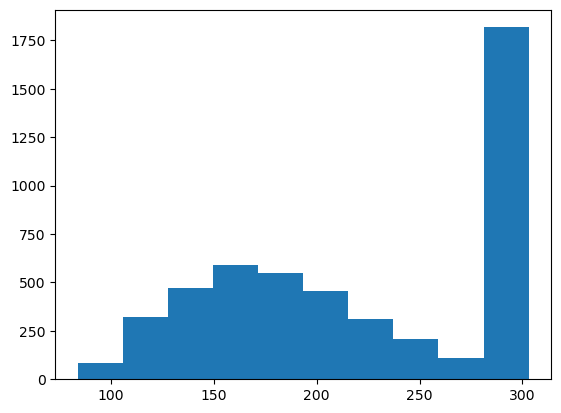

In [108]:
import matplotlib.pyplot as plt
plt.hist(tp_v['sequence'].str.len())

In [116]:
a = fn_v['sequence'].values.tolist()
b = fn_v['sequence_id'].values.tolist()
with open('fn_v.fastq', 'w') as f:
    for i in zip(a,b):
        f.write(f'@{i[1]}\n')
        f.write(i[0]+'\n')
        f.write('+\n')
        f.write('ok\n')

## Graphs

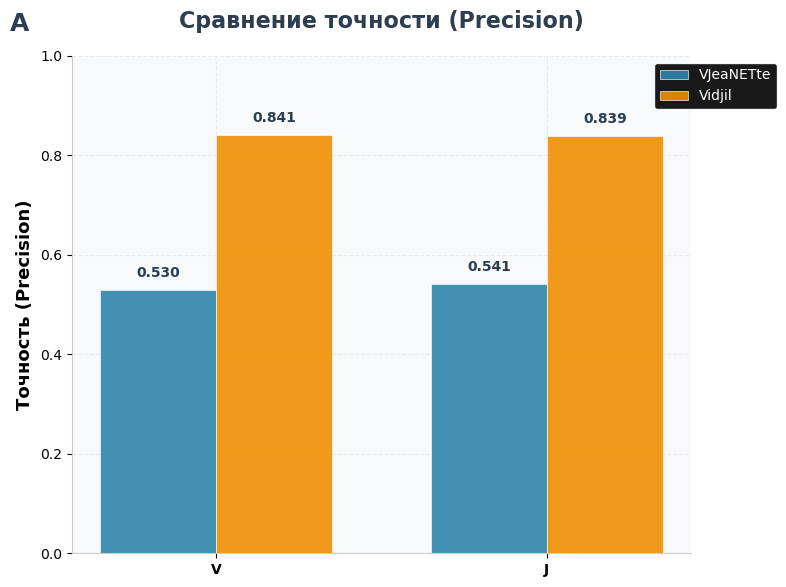

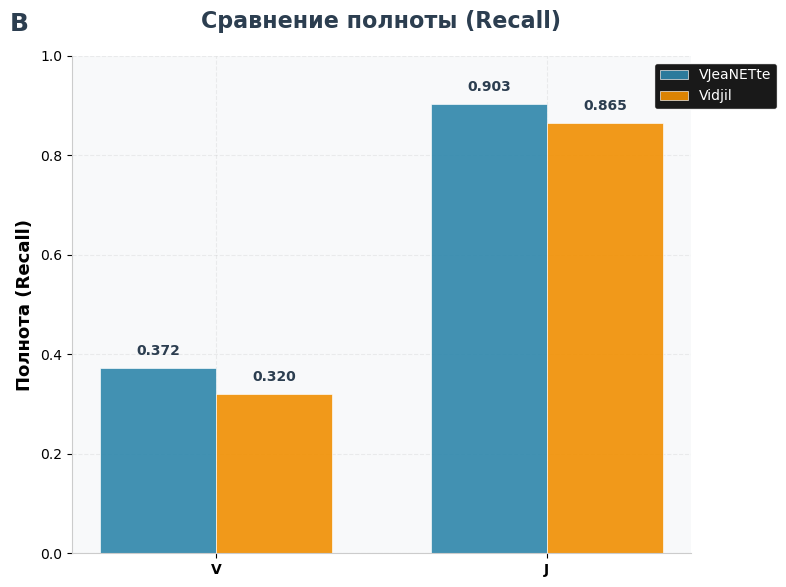

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

colors = ['#2E86AB', '#A23B72', '#F18F01']

# 1. Precision
fig1, ax1 = plt.subplots(figsize=(8, 6), facecolor='white')
ax1.set_facecolor('#f8f9fa')

labels = ["V", "J"]
x = np.arange(len(labels))
width = 0.35

precision_model = [precision_v_model, precision_j_model]
precision_vidjil = [precision_v_vidjil, precision_j_vidjil]

bars1_model = ax1.bar(x - width/2, precision_model, width, label='VJeaNETte', 
                      color=colors[0], alpha=0.9, edgecolor='white', linewidth=0.5)
bars1_vidjil = ax1.bar(x + width/2, precision_vidjil, width, label='Vidjil', 
                       color=colors[2], alpha=0.9, edgecolor='white', linewidth=0.5)

ax1.set_ylabel('Точность (Precision)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.set_axisbelow(True)

# Убираем границы (справа и сверху)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')

for bars in [bars1_model, bars1_vidjil]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, 
                fontweight='bold', color='#2c3e50')

ax1.set_title('Сравнение точности (Precision)', fontsize=16, fontweight='bold', 
              pad=20, color='#2c3e50')

# Легенда вынесена в правый верхний угол, но с отступом от графика
legend1 = ax1.legend(loc='upper right', frameon=True, fancybox=True, 
                     framealpha=0.9, edgecolor='white', bbox_to_anchor=(1.15, 1.0))
legend1.get_frame().set_facecolor('black')
plt.setp(legend1.get_texts(), color='white')

ax1.text(-0.1, 1.05, 'A', transform=ax1.transAxes, fontsize=18, 
         fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()  

fig1.savefig('precision_plot.png', transparent=True, dpi=300, bbox_inches='tight')

# 2. Recall
fig2, ax2 = plt.subplots(figsize=(8, 6), facecolor='white')
ax2.set_facecolor('#f8f9fa')

recall_model = [recall_v_model, recall_j_model]
recall_vidjil = [recall_v_vidjil, recall_jfn_v[fn_v['has_v'] & fn_v['has_j']]_vidjil] 

bars2_model = ax2.bar(x - width/2, recall_model, width, label='VJeaNETte', 
                      color=colors[0], alpha=0.9, edgecolor='white', linewidth=0.5)
bars2_vidjil = ax2.bar(x + width/2, recall_vidjil, width, label='Vidjil', 
                       color=colors[2], alpha=0.9, edgecolor='white', linewidth=0.5)

ax2.set_ylabel('Полнота (Recall)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.set_axisbelow(True)

# Убираем границы (справа и сверху)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')

for bars in [bars2_model, bars2_vidjil]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, 
                fontweight='bold', color='#2c3e50')

ax2.set_title('Сравнение полноты (Recall)', fontsize=16, fontweight='bold', 
              pad=20, color='#2c3e50')

# Легенда вынесена в правый верхний угол, но с отступом от графика
legend2 = ax2.legend(loc='upper right', frameon=True, fancybox=True, 
                     framealpha=0.9, edgecolor='white', bbox_to_anchor=(1.15, 1.0))
legend2.get_frame().set_facecolor('black')
plt.setp(legend2.get_texts(), color='white')

ax2.text(-0.1, 1.05, 'B', transform=ax2.transAxes, fontsize=18, 
         fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show() 

fig2.savefig('recall_plot.png', transparent=True, dpi=300, bbox_inches='tight')

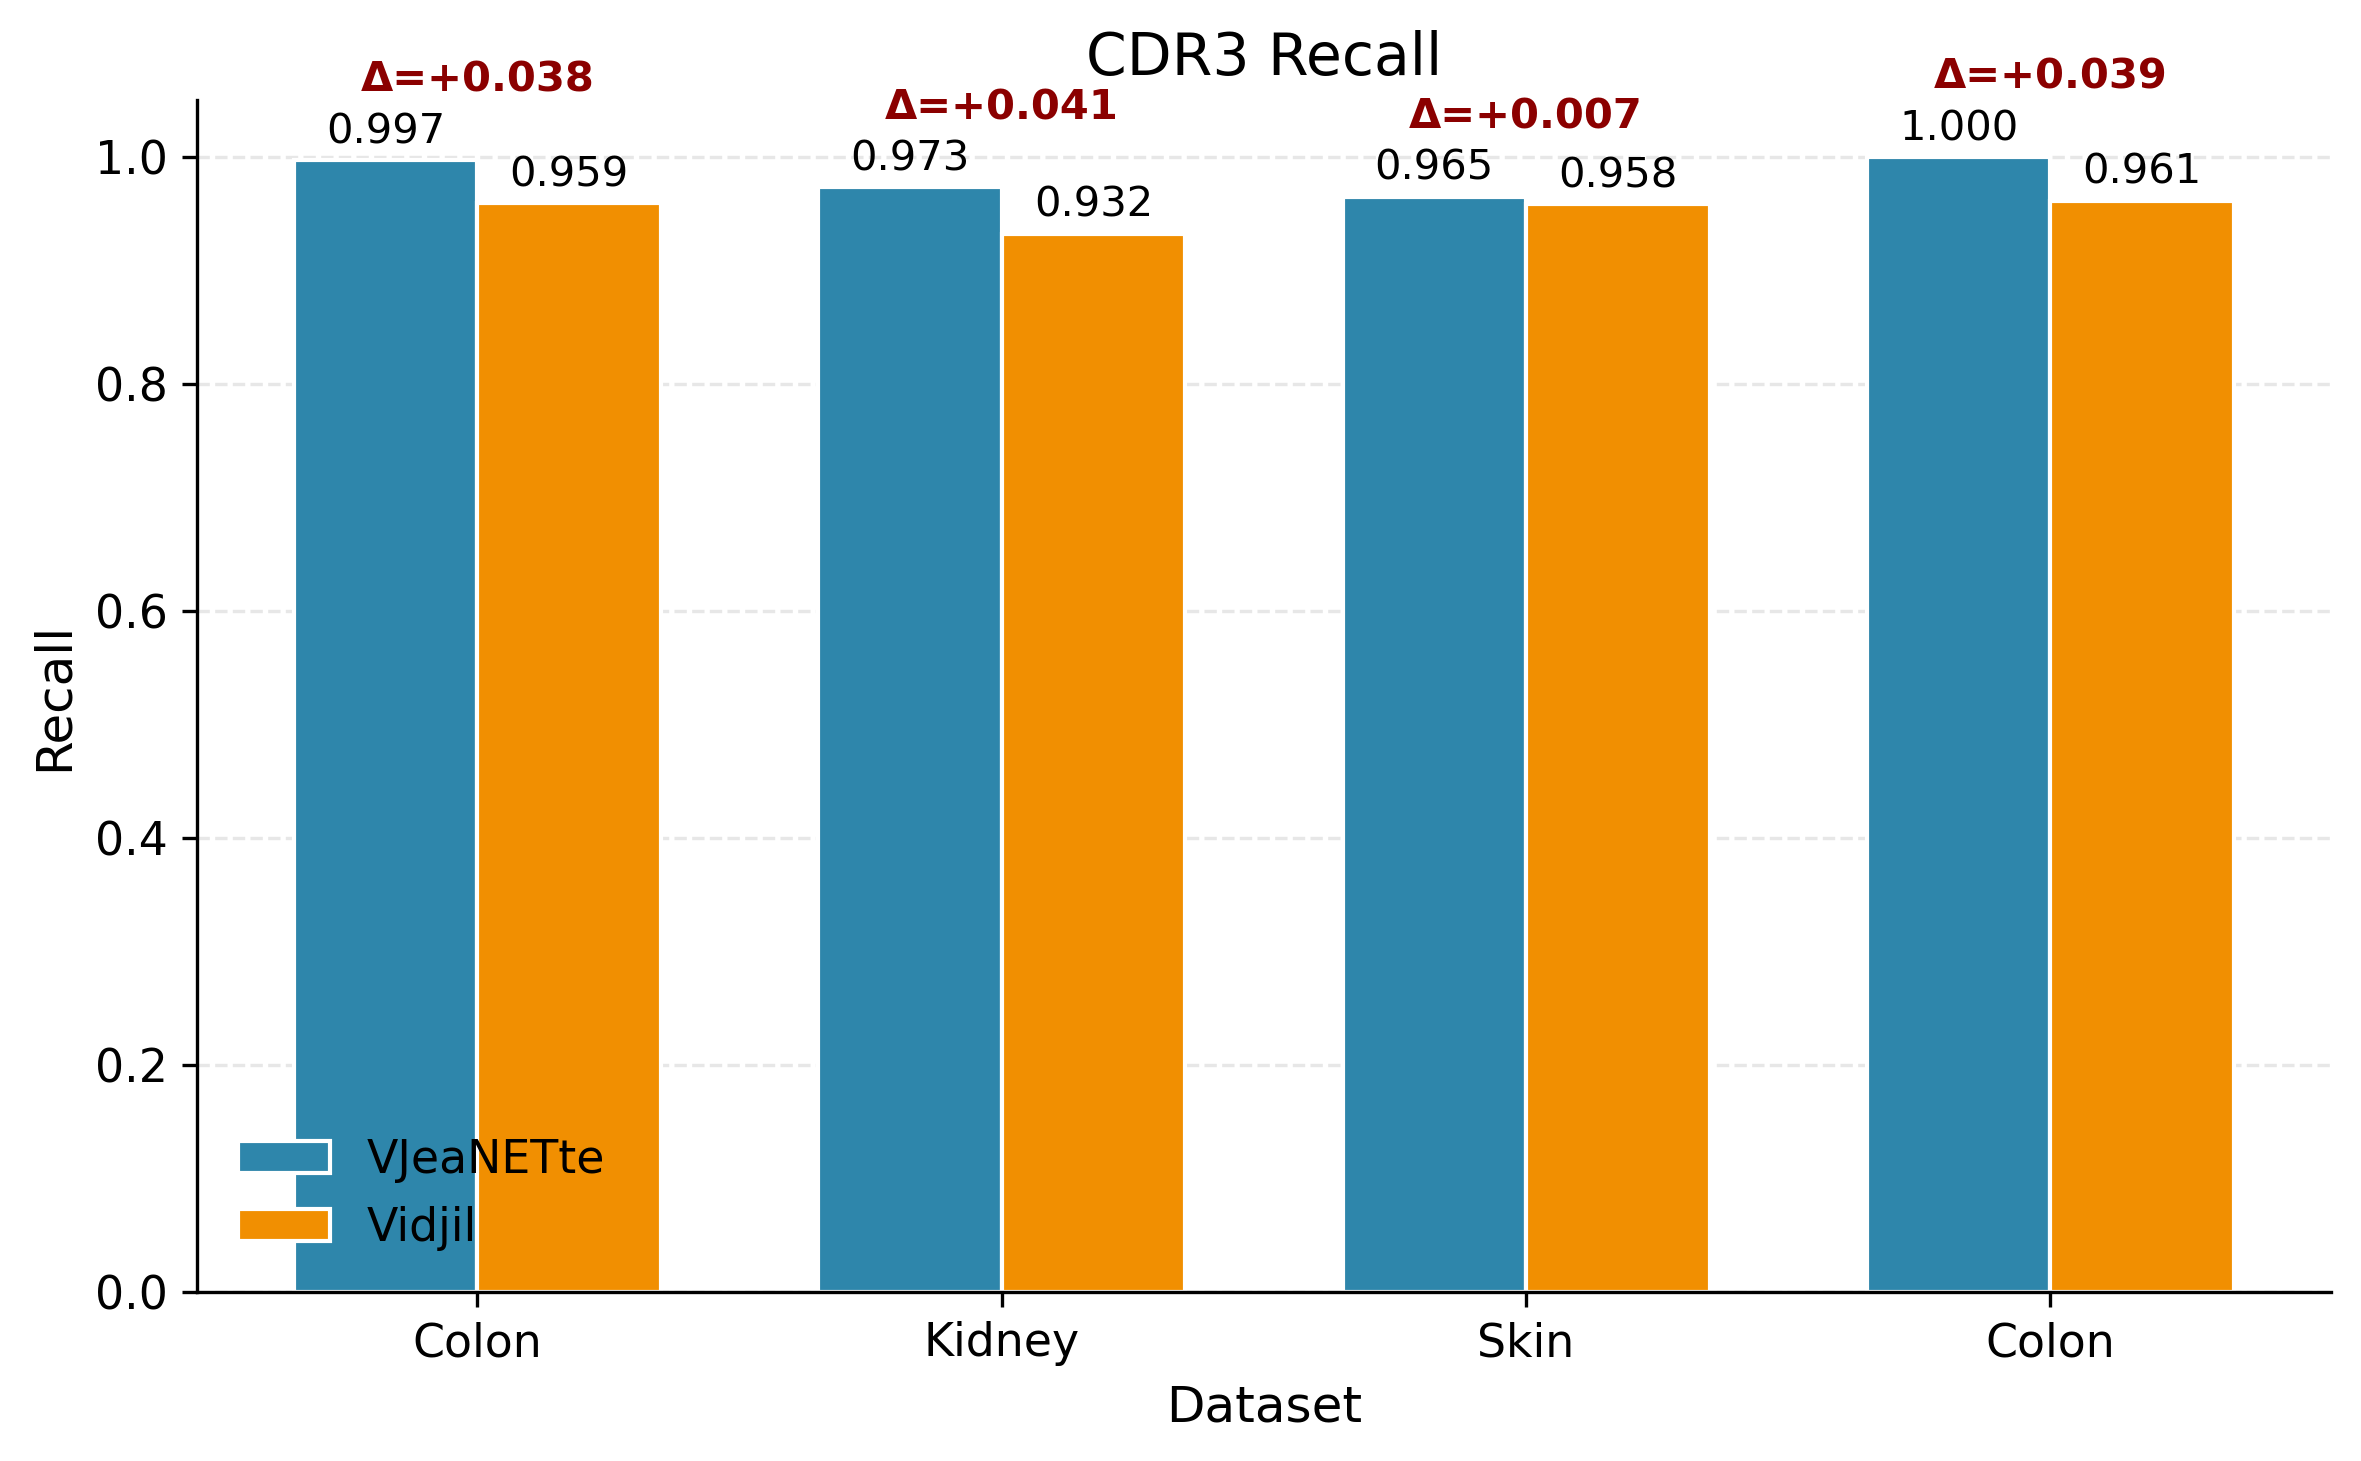

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

colors = ['#2E86AB', '#F18F01']

# -----------------------------
# INSERT YOUR VALUES
# -----------------------------
samples = [
    "Colon",
    "Kidney",
    "Skin",
    "Colon"
]

recall_model = [
    0.9971197591070927,
    0.973,
    0.965,
    0.9997216
]

recall_vidjil = [
    0.9592511373678212,
    0.932,
    0.958,
    0.9612
]
# -----------------------------

x = np.arange(len(samples))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5), dpi=300)

bars_model = ax.bar(
    x - width/2,
    recall_model,
    width,
    label="VJeaNETte",
    color=colors[0],
    edgecolor="white"
)

bars_vidjil = ax.bar(
    x + width/2,
    recall_vidjil,
    width,
    label="Vidjil",
    color=colors[1],
    edgecolor="white"
)

ax.set_ylabel("Recall")
ax.set_xlabel("Dataset")
ax.set_title("CDR3 Recall")
ax.set_xticks(x)
ax.set_xticklabels(samples)
ax.set_ylim(0, 1.05)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bars in [bars_model, bars_vidjil]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.015,
            f"{h:.3f}",
            ha="center",
            fontsize=10
        )
for i, (m, v) in enumerate(zip(recall_model, recall_vidjil)):
    diff = m - v
    ax.text(
        x[i],
        max(m, v) + 0.06,
        f"Δ={diff:+.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="darkred"
    )

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("cdr3_recall.png", dpi=300, bbox_inches="tight")
plt.show()

Wilcoxon statistic = 0.0
p-value = 0.1250


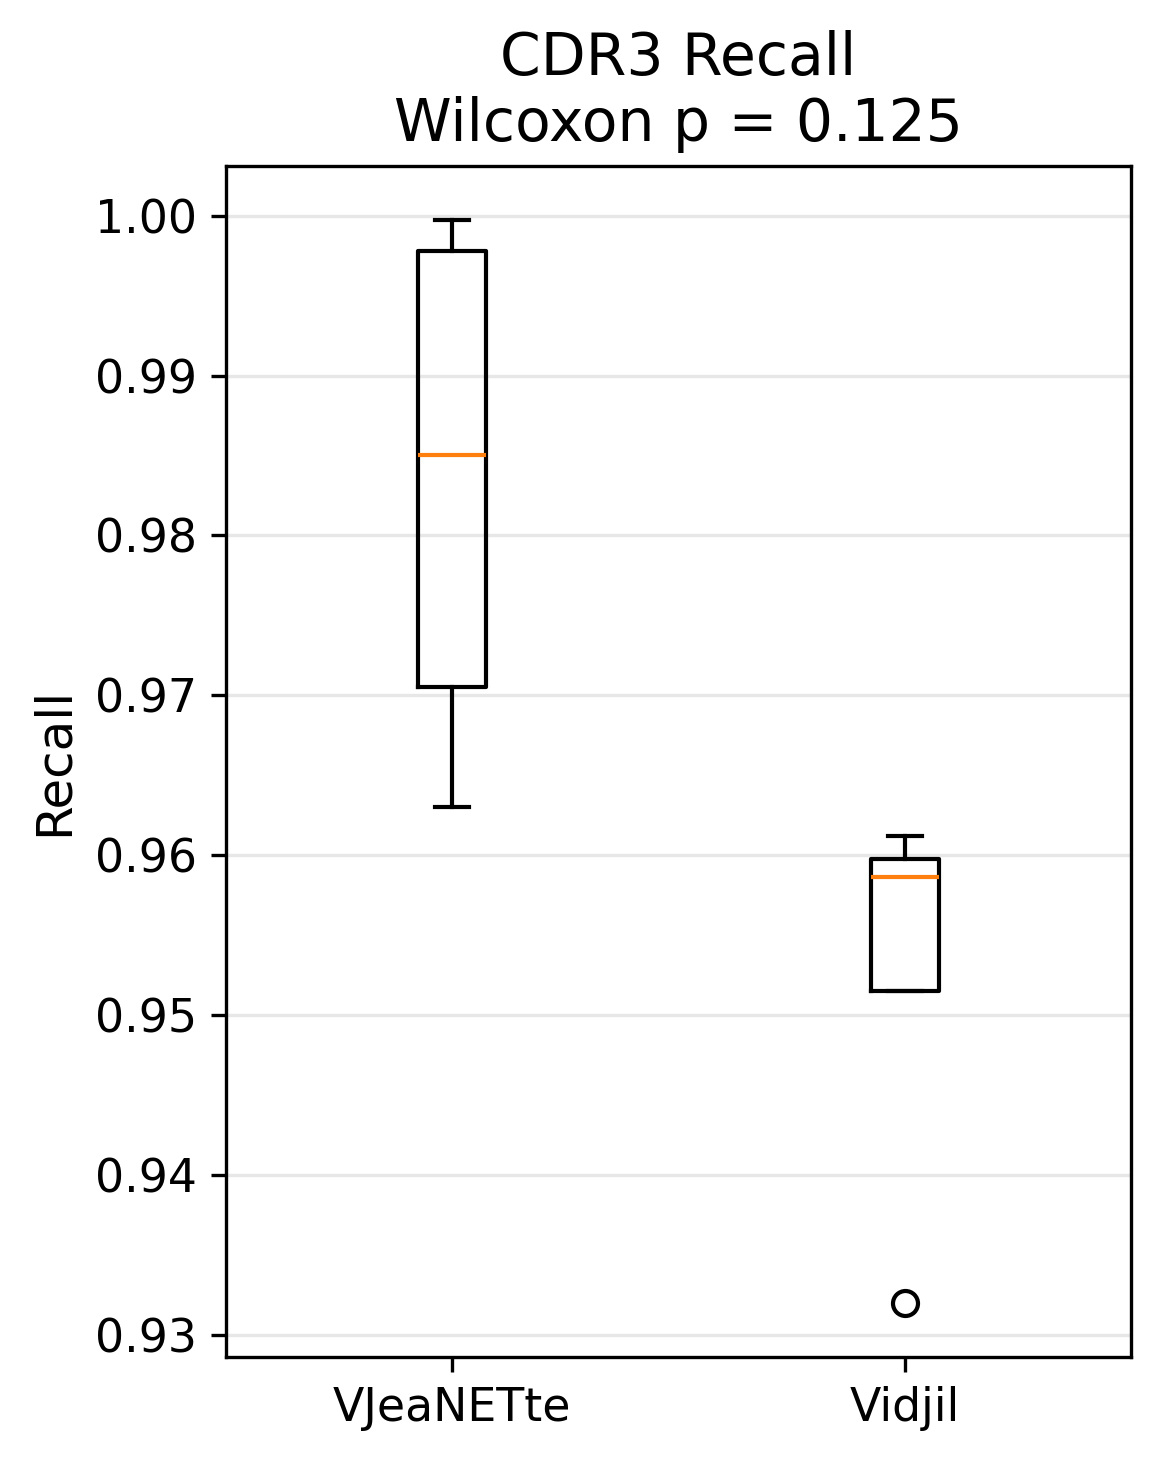

In [189]:
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

recall_model = [
    0.9971197591070927,
    0.973,
    0.963,
    0.9997216
]

recall_vidjil = [
    0.9592511373678212,
    0.932,
    0.958,
    0.9612
]

stat, p = wilcoxon(recall_model, recall_vidjil)

print(f"Wilcoxon statistic = {stat}")
print(f"p-value = {p:.4f}")

plt.figure(figsize=(4,5), dpi=300)

plt.boxplot(
    [recall_model, recall_vidjil],
    tick_labels=["VJeaNETte", "Vidjil"]
)

plt.ylabel("Recall")
plt.title(f"CDR3 Recall\nWilcoxon p = {p:.3f}")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

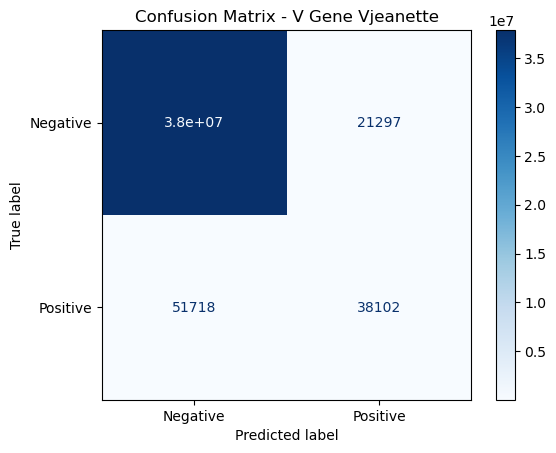

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Сбрасываем настройки стиля
plt.rcParams.update(plt.rcParamsDefault)

ConfusionMatrixDisplay.from_predictions(data_merged['has_v_ok_x'], data_merged['has_v_ok_y'], 
                                        display_labels=['Negative', 'Positive'],
                                        cmap='Blues')
plt.title('Confusion Matrix - V Gene Vjeanette')
plt.show()

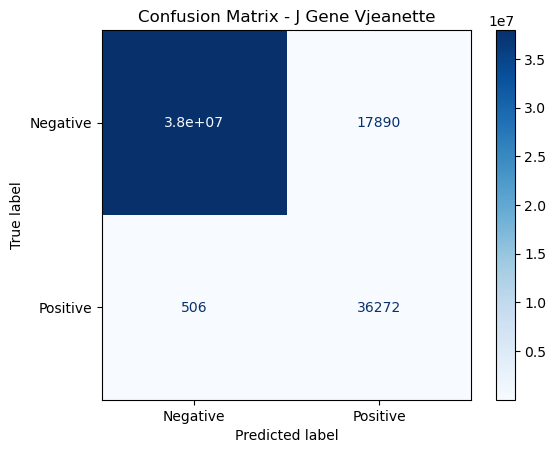

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Сбрасываем настройки стиля
plt.rcParams.update(plt.rcParamsDefault)

ConfusionMatrixDisplay.from_predictions(data_merged['has_j_ok_x'], data_merged['has_j_ok_y'], 
                                        display_labels=['Negative', 'Positive'],
                                        cmap='Blues')
plt.title('Confusion Matrix - J Gene Vjeanette')

plt.show()

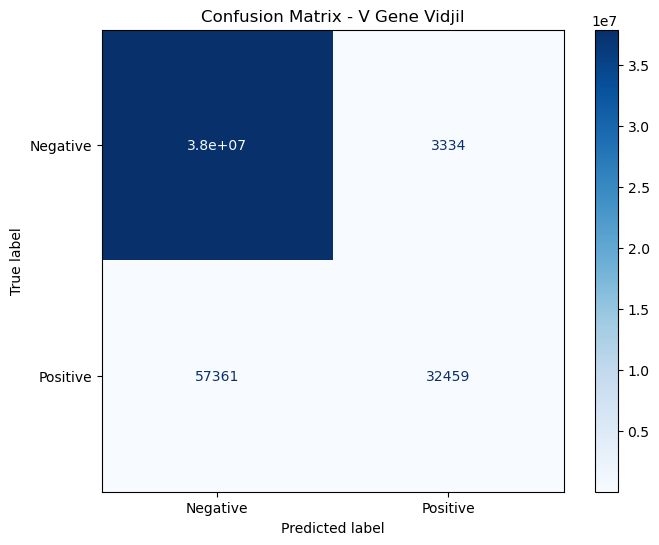

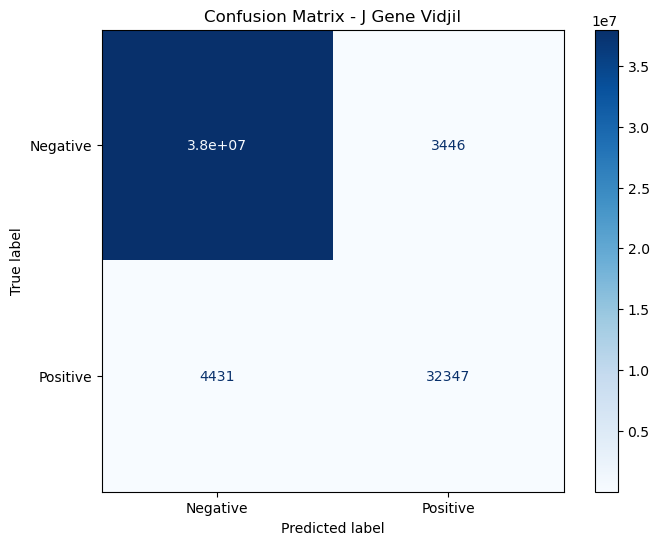

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Восстанавливаем метки
y_true_v = np.array([1]*TP_v_vidjil + [0]*FP_v_vidjil + [1]*FN_v_vidjil + [0]*TN_v_vidjil)
y_pred_v = np.array([1]*TP_v_vidjil + [1]*FP_v_vidjil + [0]*FN_v_vidjil + [0]*TN_v_vidjil)

y_true_j = np.array([1]*TP_j_vidjil + [0]*FP_j_vidjil + [1]*FN_j_vidjil + [0]*TN_j_vidjil)
y_pred_j = np.array([1]*TP_j_vidjil + [1]*FP_j_vidjil + [0]*FN_j_vidjil + [0]*TN_j_vidjil)

# Строим confusion matrix для V-генов
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_true_v, y_pred_v, 
                                        display_labels=['Negative', 'Positive'],
                                        cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix - V Gene Vidjil')
plt.show()

# Строим confusion matrix для J-генов
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_true_j, y_pred_j, 
                                        display_labels=['Negative', 'Positive'],
                                        cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix - J Gene Vidjil')
plt.show()

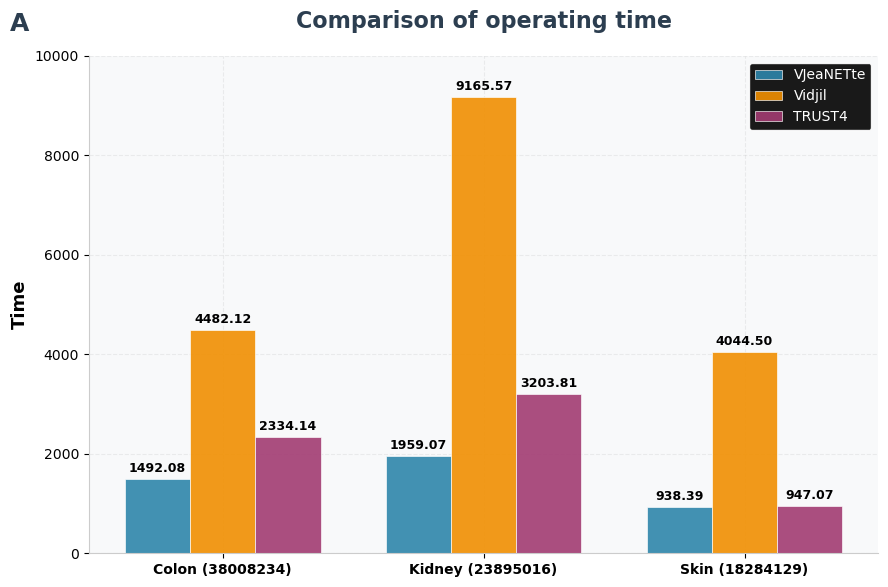

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

colors = ['#2E86AB', '#A23B72', '#F18F01']

fig1, ax1 = plt.subplots(figsize=(9, 6), facecolor='white')
ax1.set_facecolor('#f8f9fa')

labels = ["Colon (38008234)", "Kidney (23895016)", "Skin (18284129)"]
x = np.arange(len(labels))
width = 0.25  # уменьшаем ширину, чтобы поместилось 3 столбца

# Данные
time_model1 = [1492.08, 1959.07, 938.39]      # VJeaNETte
time_model2 = [4482.12, 9165.57, 4044.50]     # Vidjil
time_model3 = [2334.14, 3203.81, 947.07]     # Третья модель

bars1 = ax1.bar(
    x - width,
    time_model1,
    width,
    label='VJeaNETte',
    color=colors[0],
    alpha=0.9,
    edgecolor='white',
    linewidth=0.5
)

bars2 = ax1.bar(
    x,
    time_model2,
    width,
    label='Vidjil',
    color=colors[2],
    alpha=0.9,
    edgecolor='white',
    linewidth=0.5
)

bars3 = ax1.bar(
    x + width,
    time_model3,
    width,
    label='TRUST4',
    color=colors[1],
    alpha=0.9,
    edgecolor='white',
    linewidth=0.5
)

ax1.set_ylabel('Time', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold')
ax1.set_ylim(0, 10000)

ax1.grid(True, alpha=0.2, linestyle='--')
ax1.set_axisbelow(True)

# Убираем лишние границы
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')

# Подписи над столбцами
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height + 80,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

ax1.set_title(
    'Comparison of operating time',
    fontsize=16,
    fontweight='bold',
    pad=20,
    color='#2c3e50'
)

legend1 = ax1.legend(
    loc='upper right',
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor='white'
)
legend1.get_frame().set_facecolor('black')
plt.setp(legend1.get_texts(), color='white')

ax1.text(
    -0.1,
    1.05,
    'A',
    transform=ax1.transAxes,
    fontsize=18,
    fontweight='bold',
    color='#2c3e50'
)

plt.tight_layout()
plt.savefig('time_plot.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

In [58]:
data_reference.columns

Index(['Unnamed: 0', 'sequence', 'sequence_id', 'v_sequence_start',
       'v_sequence_end', 'j_sequence_start', 'j_sequence_end', 'cdr3_start',
       'cdr3_end', 'best_v_identity', 'best_j_identity', 'best_v_score',
       'best_j_score', 'has_v', 'has_j', 'has_v_ok', 'has_j_ok'],
      dtype='object')